# create a simple network

## Prepare - assuming persistent data set has been created in the previous notebook

In [1]:
 #============= Globals ==========
from mri_dl import (
    MRIUndersampledDataset,
    ResidualUNet,
    ModelConfig,
    train_model,
    load_checkpoint,
    predict_tensor,
)
from torch.utils.data import DataLoader
import torch
import os
from pathlib import Path

HPC = False

#============= main ==========
#set here the path to the course data brain age folder
data_path = '../../../../../../../mri_dataset/brain_age'

data_path = os.path.abspath(data_path)
print(f'Data path: {data_path}')
os.chdir(data_path)


experiment_config = ModelConfig(
    plane="coronal",
    retain_ratio=0.30,
    epochs=65,
    #epochs=2,
    batch_size=32,
    learning_rate=5e-4,
    weight_decay=2e-5,
    random_seed=42,
    num_workers=0 if os.name == "nt" else 4,
    data_consistency_enabled=True,
    per_image_csv_logging=True,
    #set here the path to the split data set you've made
    #default is to use the split data set created in the previous notebook
    data_root= Path(os.getcwd() + r'../../../../../../../notebook_5_undersampled_dataset_split').resolve(),
    #set here the path to the required results folder
    result_root=Path(os.getcwd() + r'../../../../../../../notebook_5_undersampled_results').resolve(),)


Data path: C:\mri_dataset\brain_age


## Create a dataset for a single plane, and a single retain ratio

In [2]:
data_sets_root = experiment_config.data_root
train_dataset = MRIUndersampledDataset(
    data_sets_root / "train",
    csv_name = "samples.csv",
    plane=experiment_config.plane.capitalize(),
    retain_ratio=experiment_config.retain_ratio,
    load_mask=False,
)
val_dataset = MRIUndersampledDataset(
    data_sets_root / "val",
    csv_name = "samples.csv",
    plane=experiment_config.plane.capitalize(),
    retain_ratio=experiment_config.retain_ratio,
    load_mask=False,
)
test_dataset = MRIUndersampledDataset(
    data_sets_root / "test",
    csv_name = "samples.csv",
    plane=experiment_config.plane.capitalize(),
    retain_ratio=experiment_config.retain_ratio,
    load_mask=True
)

sample = train_dataset[0]
print(sample["sample_id"])
print(sample["input"].shape)
print(sample["target"].shape)
print(sample["delta_target"].shape)
print(sample["retain_ratio"])


Sub0113_Ses1_row001564_coronal_s0062_r30_u000
torch.Size([1, 99, 90])
torch.Size([1, 99, 90])
torch.Size([1, 99, 90])
tensor(0.3000)


## Show a sample

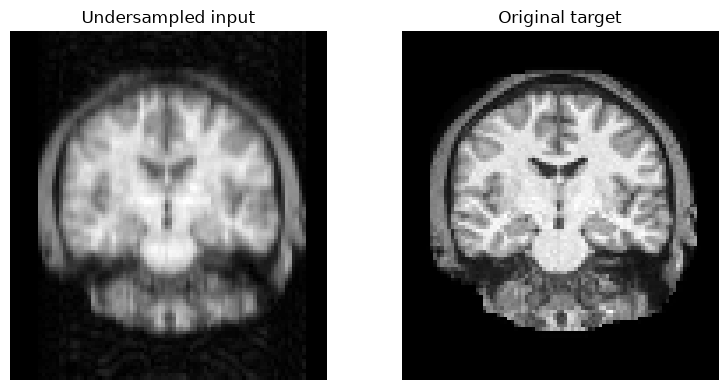

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(sample["input"][0], cmap="gray")
axes[0].set_title("Undersampled input")
axes[0].axis("off")

axes[1].imshow(sample["target"][0], cmap="gray")
axes[1].set_title("Original target")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Create data loader

In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=experiment_config.batch_size,
    shuffle=True,
    num_workers=experiment_config.num_workers,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=experiment_config.batch_size,
    shuffle=False,
    num_workers=experiment_config.num_workers,
    pin_memory=torch.cuda.is_available(),
)


## Create a residual UNET model. Train it to predict the difference between the undersampled input and the original target.

In [5]:
train = True
if train:
    model_kwargs = experiment_config.model_kwargs
    model = ResidualUNet(**model_kwargs)
    train_config = experiment_config.make_train_config()
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        train_config=train_config,
        model_kwargs=model_kwargs,
        experiment_config=experiment_config,
    )


Training on device: cuda
Training model. start: 15:13:22
Epoch 001/065 | train=0.074131 | val=0.042404 *
Saving checkpoint to C:\notebook_5_undersampled_results\coronal\retain_30\best_model.pt
Epoch 002/065 | train=0.041376 | val=0.041214 *
Saving checkpoint to C:\notebook_5_undersampled_results\coronal\retain_30\best_model.pt
Epoch 003/065 | train=0.039345 | val=0.038185 *
Saving checkpoint to C:\notebook_5_undersampled_results\coronal\retain_30\best_model.pt
Epoch 004/065 | train=0.037798 | val=0.038048 *
Saving checkpoint to C:\notebook_5_undersampled_results\coronal\retain_30\best_model.pt
Epoch 005/065 | train=0.036033 | val=0.036155 *
Saving checkpoint to C:\notebook_5_undersampled_results\coronal\retain_30\best_model.pt
Epoch 006/065 | train=0.035178 | val=0.034835 *
Saving checkpoint to C:\notebook_5_undersampled_results\coronal\retain_30\best_model.pt
Epoch 007/065 | train=0.035129 | val=0.038890
Epoch 008/065 | train=0.034538 | val=0.034224 *
Saving checkpoint to C:\notebook_

## Load the model

This can be used without training, if the model has already been trained and saved to a checkpoint.

In [6]:
print (f"model to be loaded from {experiment_config.result_dir / 'best_model.pt'}")
loaded_model, checkpoint = load_checkpoint(
    checkpoint_path=experiment_config.result_dir / "best_model.pt",
    model_class=ResidualUNet,
)
loaded_model.visualize()
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["validation_loss"])


model to be loaded from C:\notebook_5_undersampled_results\coronal\retain_30\best_model.pt

MODEL EXECUTION TRACE
01. enc1.block.0 [Conv2d] | input=(1, 1, 256, 256) -> output=(1, 16, 256, 256)
02. enc1.block.1 [BatchNorm2d] | input=(1, 16, 256, 256) -> output=(1, 16, 256, 256)
03. enc1.block.2 [ReLU] | input=(1, 16, 256, 256) -> output=(1, 16, 256, 256)
04. enc1.block.3 [Conv2d] | input=(1, 16, 256, 256) -> output=(1, 16, 256, 256)
05. enc1.block.4 [BatchNorm2d] | input=(1, 16, 256, 256) -> output=(1, 16, 256, 256)
06. enc1.block.5 [ReLU] | input=(1, 16, 256, 256) -> output=(1, 16, 256, 256)
07. pool [MaxPool2d] | input=(1, 16, 256, 256) -> output=(1, 16, 128, 128)
08. enc2.block.0 [Conv2d] | input=(1, 16, 128, 128) -> output=(1, 32, 128, 128)
09. enc2.block.1 [BatchNorm2d] | input=(1, 32, 128, 128) -> output=(1, 32, 128, 128)
10. enc2.block.2 [ReLU] | input=(1, 32, 128, 128) -> output=(1, 32, 128, 128)
11. enc2.block.3 [Conv2d] | input=(1, 32, 128, 128) -> output=(1, 32, 128, 128)
12.

## Run inference on an example from test set

In [7]:
num_examples = min(5, len(test_dataset))
if num_examples == 0:
    raise ValueError("test_dataset is empty")
random_indices = torch.randperm(len(test_dataset))[:num_examples].tolist()

examples = []
for idx in random_indices:
    test_sample = test_dataset[idx]
    prediction = predict_tensor(
        model=loaded_model,
        input_tensor=test_sample["input"],
    )
    row = test_dataset.samples.iloc[idx]
    volume_name = Path(str(row["resolved_volume_path"])).name if "resolved_volume_path" in row.index else "unknown"
    slice_index = int(row["slice_index"]) if "slice_index" in row.index else -1
    examples.append(
        {
            "idx": idx,
            "sample": test_sample,
            "prediction": prediction,
            "volume_name": volume_name,
            "slice_index": slice_index,
        }
    )

print(f"Showing {len(examples)} random test samples: {random_indices}")

Showing 5 random test samples: [192, 21, 120, 56, 172]


## Show the prediction

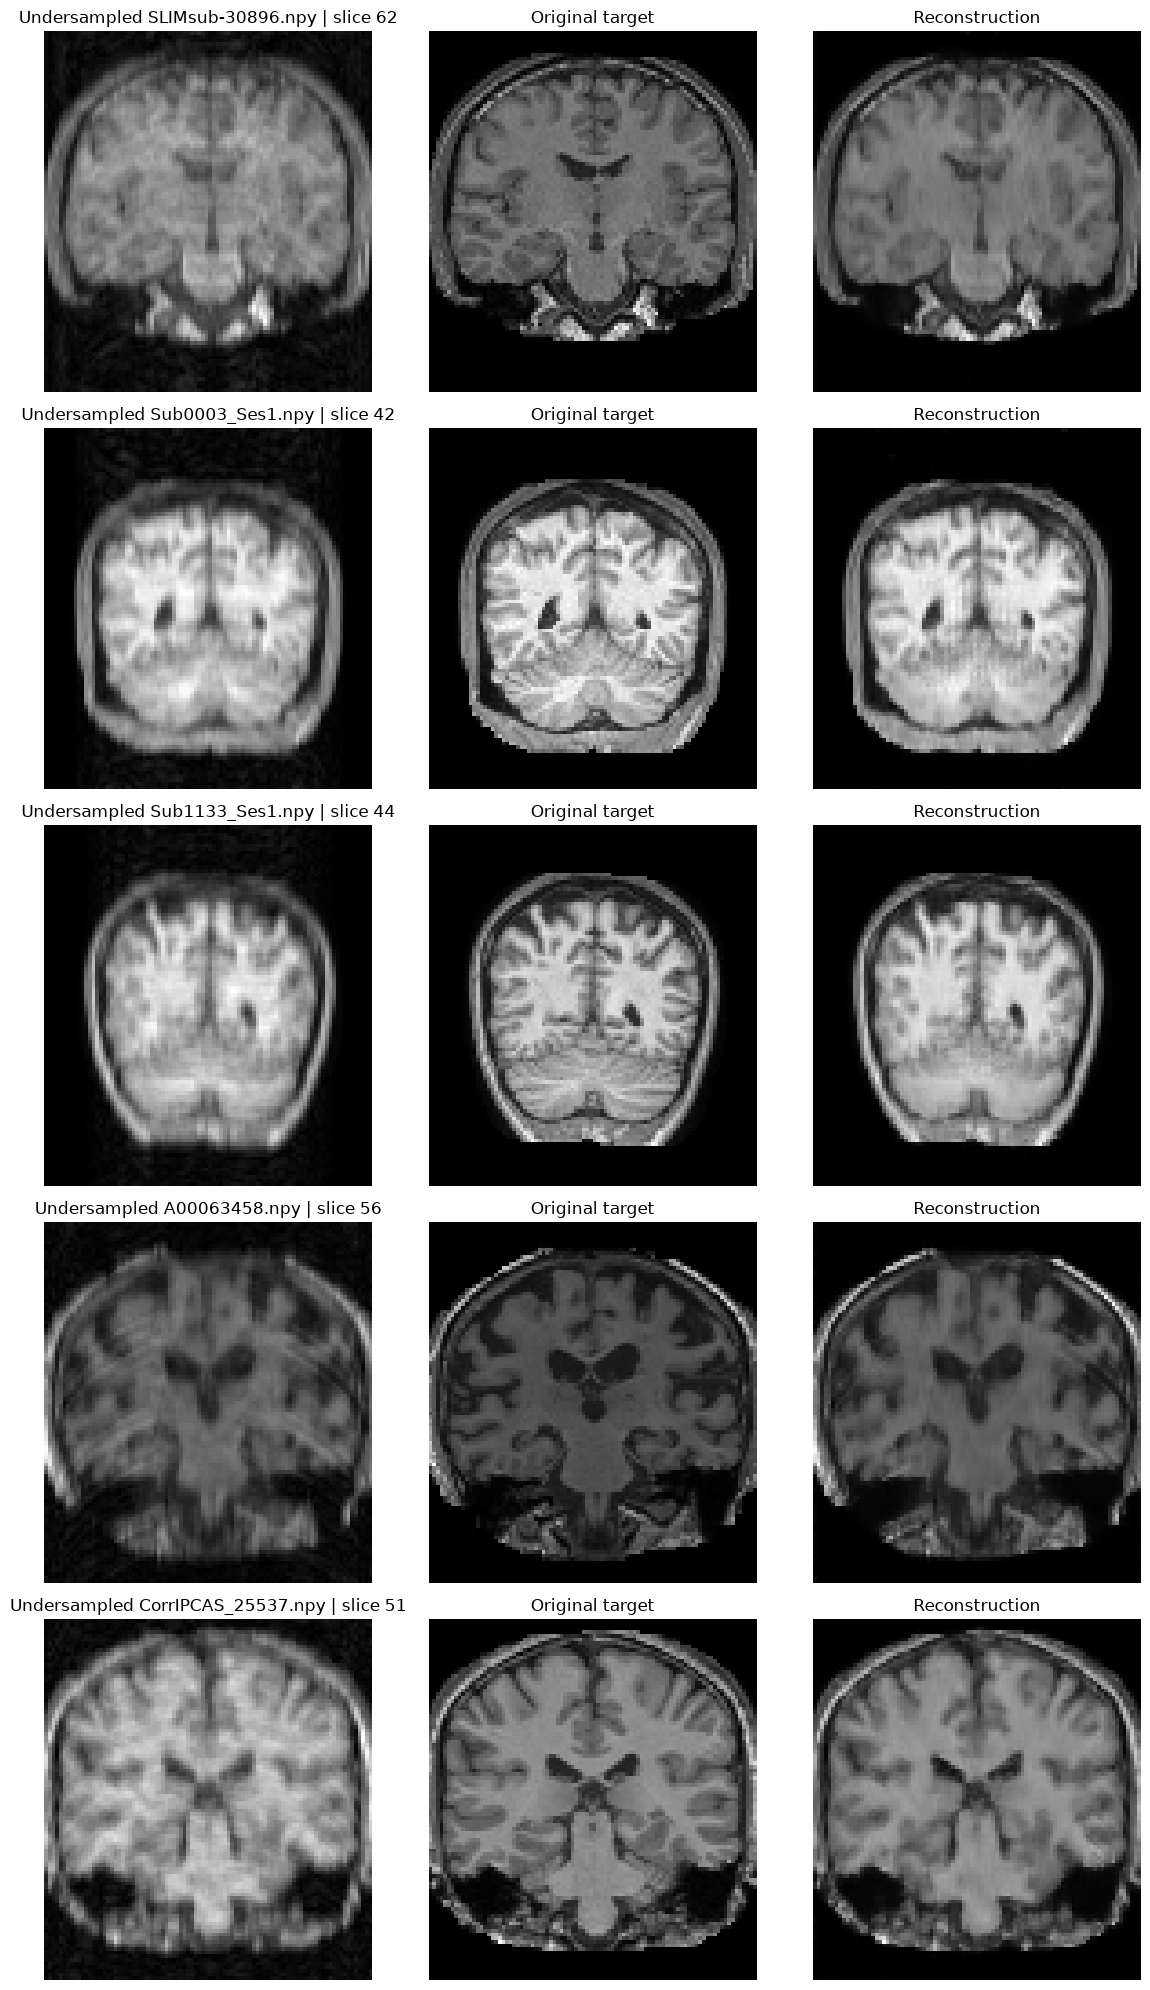

In [8]:
fig, axes = plt.subplots(len(examples), 3, figsize=(12, 4 * len(examples)))
if len(examples) == 1:
    axes = axes[None, ...]
for row_idx, example in enumerate(examples):
    test_sample = example["sample"]
    prediction = example["prediction"]
    volume_name = example["volume_name"]
    slice_index = example["slice_index"]
    axes[row_idx, 0].imshow(test_sample["input"][0], cmap="gray")
    axes[row_idx, 0].set_title(f"Undersampled {volume_name} | slice {slice_index}")
    axes[row_idx, 0].axis("off")
    axes[row_idx, 1].imshow(test_sample["target"][0], cmap="gray")
    axes[row_idx, 1].set_title("Original target")
    axes[row_idx, 1].axis("off")
    axes[row_idx, 2].imshow(prediction[0], cmap="gray")
    axes[row_idx, 2].set_title("Reconstruction")
    axes[row_idx, 2].axis("off")
plt.tight_layout()
plt.show()


## calculate the PSNR of the prediction

In [9]:
import pandas as pd
from src.metrices import calculate_psnr, calculate_ssim

rows = []
for example in examples:
    test_sample = example["sample"]
    prediction = example["prediction"]
    us_psnr = calculate_psnr(test_sample["target"][0].numpy(), test_sample["input"][0].numpy())
    rec_psnr = calculate_psnr(test_sample["target"][0].numpy(), prediction[0].numpy())
    us_ssim = calculate_ssim(test_sample["target"][0].numpy(), test_sample["input"][0].numpy())
    rec_ssim = calculate_ssim(test_sample["target"][0].numpy(), prediction[0].numpy())
    rows.append({
        "Volume": example["volume_name"],
        "Slice": example["slice_index"],
        "Undersampled PSNR": round(us_psnr, 3),
        "Reconstructed PSNR": round(rec_psnr, 3),
        "Undersampled SSIM": round(us_ssim, 4),
        "Reconstructed SSIM": round(rec_ssim, 4),
        "SSIM Gain": round(rec_ssim - us_ssim, 4),
        "Gain": round(rec_psnr - us_psnr, 3),
    })

# Append an average summary row (computed only over the actual example rows)
n = len(rows)
rows.append({
    "Volume": "AVERAGE",
    "Slice": "",
    "Undersampled PSNR": round(sum(r["Undersampled PSNR"] for r in rows[:n]) / n, 3),
    "Reconstructed PSNR": round(sum(r["Reconstructed PSNR"] for r in rows[:n]) / n, 3),
    "Undersampled SSIM": round(sum(r["Undersampled SSIM"] for r in rows[:n]) / n, 4),
    "Reconstructed SSIM": round(sum(r["Reconstructed SSIM"] for r in rows[:n]) / n, 4),
    "SSIM Gain": round(sum(r["SSIM Gain"] for r in rows[:n]) / n, 4),
    "Gain": round(sum(r["Gain"] for r in rows[:n]) / n, 3),
})

# Keep Volume/Slice as regular columns (not index) so pandas Styler works
# regardless of whether (Volume, Slice) pairs are unique across samples.
psnr_df = pd.DataFrame(rows)

display(
    psnr_df.style
        .highlight_max(subset=["Reconstructed PSNR", "Gain"], color="lightgreen")
        .highlight_max(subset=["Reconstructed SSIM", "SSIM Gain"], color="lightgreen")
        .highlight_min(subset=["Gain"], color="lightyellow")
        .highlight_min(subset=["SSIM Gain"], color="lightyellow")
        .format({
            "Undersampled PSNR": "{:.3f}",
            "Reconstructed PSNR": "{:.3f}",
            "Gain": "{:.3f}",
            "Undersampled SSIM": "{:.4f}",
            "Reconstructed SSIM": "{:.4f}",
            "SSIM Gain": "{:.4f}",
            "Slice": "{}",
        })
        .set_properties(subset=["Volume", "Slice"], **{"font-weight": "bold"})
        .hide(axis="index")
)


Volume,Slice,Undersampled PSNR,Reconstructed PSNR,Undersampled SSIM,Reconstructed SSIM,SSIM Gain,Gain
SLIMsub-30896.npy,62,23.599,26.032,0.6258,0.8572,0.2313,2.432
Sub0003_Ses1.npy,42,22.499,23.840,0.7066,0.9060,0.1995,1.341
Sub1133_Ses1.npy,44,22.261,23.998,0.7102,0.8946,0.1845,1.737
A00063458.npy,56,24.477,27.096,0.6822,0.8437,0.1615,2.620
CorrIPCAS_25537.npy,51,23.319,25.588,0.7241,0.8651,0.1410,2.268
AVERAGE,,23.231,25.311,0.6898,0.8733,0.1836,2.080
